# Predicción del gasto de clientes en e-commerce  
### Proyecto Módulo 6 – Aprendizaje de Máquina Supervisado  

**Empresa:** RetailData Analytics  

**Rol asumido:** Especialista en Ciencia de Datos  

**Autor:** Manuel Quintana  

**Curso:** Fundamentos de Ciencia de Datos  

**Módulo:** Aprendizaje de Máquina Supervisado  

**Herramientas utilizadas:**  
Python, NumPy, Pandas, Scikit-Learn, Matplotlib, Seaborn  





## Descripción del proyecto

Este proyecto tiene como objetivo desarrollar un modelo de aprendizaje automático capaz de predecir el gasto anual de clientes en una plataforma de comercio electrónico. Para ello, se utilizan datos relacionados con el comportamiento de los usuarios dentro del sitio web y la aplicación móvil.

A lo largo del análisis se implementa el pipeline completo de Machine Learning supervisado, incluyendo exploración de datos, preprocesamiento, entrenamiento de modelos de regresión, evaluación mediante métricas de desempeño y optimización del modelo final.

## 1. Introducción

En el comercio electrónico, comprender el comportamiento de los clientes es fundamental para mejorar las estrategias de marketing y personalizar las ofertas.

En este proyecto se desarrollará un modelo de aprendizaje automático supervisado capaz de predecir el gasto anual de los clientes de una plataforma de e-commerce. Para ello, se utilizará un conjunto de datos que contiene información sobre el comportamiento de los usuarios dentro del sitio web y la aplicación móvil.

El objetivo principal es entrenar y evaluar distintos modelos de regresión que permitan estimar el monto anual que un cliente podría gastar, utilizando variables relacionadas con su interacción con la plataforma.

## Lección 1: Fundamentos del aprendizaje de máquina

El aprendizaje automático (Machine Learning) permite construir modelos capaces de aprender patrones a partir de datos para realizar predicciones o tomar decisiones.

Existen dos tipos principales de problemas en aprendizaje supervisado:

**Clasificación:**  
Se utiliza cuando la variable objetivo es categórica. El modelo debe asignar cada observación a una categoría o clase.

**Regresión:**  
Se utiliza cuando la variable objetivo es numérica y continua. El modelo intenta predecir un valor numérico.

En este proyecto el objetivo es predecir el gasto anual de los clientes de una plataforma de comercio electrónico. Dado que la variable objetivo **Yearly Amount Spent** es un valor numérico continuo, este problema corresponde a un **problema de regresión supervisada**.

### Pipeline típico de un proyecto de Machine Learning

Un proyecto de aprendizaje automático generalmente sigue las siguientes etapas:

1. Comprensión del problema
2. Recolección y carga de datos
3. Exploración de datos
4. Preprocesamiento
5. Entrenamiento del modelo
6. Evaluación del modelo
7. Optimización del modelo
8. Implementación o interpretación de resultados

## Lección 2: Nivel de ajuste del modelo y validación cruzada

En el aprendizaje automático es fundamental evaluar si un modelo se ajusta adecuadamente a los datos. Un modelo bien ajustado debe ser capaz de aprender patrones del conjunto de entrenamiento y al mismo tiempo generalizar correctamente a datos nuevos.

Existen dos problemas comunes relacionados con el ajuste del modelo:

**Sobreajuste (Overfitting):**  
Ocurre cuando el modelo aprende demasiado bien los datos de entrenamiento, incluyendo el ruido presente en ellos. Esto provoca que el modelo tenga un rendimiento muy bueno en el conjunto de entrenamiento pero pobre en el conjunto de prueba.

**Subajuste (Underfitting):**  
Ocurre cuando el modelo es demasiado simple y no logra capturar los patrones presentes en los datos. En este caso el modelo presenta un rendimiento bajo tanto en los datos de entrenamiento como en los datos de prueba.

Para evaluar el nivel de ajuste del modelo se comparan los errores obtenidos en el conjunto de entrenamiento y en el conjunto de prueba.

Además, se puede utilizar la técnica de **validación cruzada (cross-validation)** para obtener una estimación más robusta del rendimiento del modelo.

## 2. Importación de librerías

In [372]:
# Librería Pandas (manipulación y análisis de datos tabulares)
import pandas as pd

# NumPy (operaciones numéricas y matemáticas)
import numpy as np


#  Matplotlib (creación de gráficos y visualizaciones básicas)
import matplotlib.pyplot as plt

#  Seaborn  (genera visualizaciones estadísticas más avanzadas)
import seaborn as sns


# función train_test_split (dividir los datos en conjuntos de entrenamiento y prueba)
from sklearn.model_selection import train_test_split

# modelo de regresión lineal (realizar predicciones sobre variables numéricas)
from sklearn.linear_model import LinearRegression

## 3. Carga del conjunto de datos

In [373]:
# Cargar el dataset "Ecommerce Customers" en un DataFrame de Pandas
df = pd.read_csv("Ecommerce Customers.csv")

# Mostrar las primeras 5 filas del dataset 
df.head()

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


## 4. Exploración inicial de los datos

En esta sección se realiza una exploración preliminar del conjunto de datos con el objetivo de comprender su estructura, identificar los tipos de variables presentes y detectar posibles problemas en la calidad de los datos.

Para ello se analizarán aspectos como:

- La estructura general del dataset.
- El número de filas y columnas.
- Los tipos de datos de cada variable.
- La presencia de valores nulos o faltantes.
- Estadísticas descriptivas básicas de las variables numéricas.

Este análisis exploratorio inicial permite tener una primera comprensión del conjunto de datos antes de aplicar procesos de limpieza, transformación y modelado.

In [374]:
# Mostrar información general del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB


In [375]:
# Mostrar estadísticas descriptivas de las variables numéricas
df.describe()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


In [376]:
# Verificar si existen valores nulos en el dataset
df.isnull().sum()

Email                   0
Address                 0
Avatar                  0
Avg. Session Length     0
Time on App             0
Time on Website         0
Length of Membership    0
Yearly Amount Spent     0
dtype: int64

**Interpretación**

El resultado de `df.info()` indica que todas las columnas del dataset contienen 500 valores no nulos, lo que significa que no existen datos faltantes en el conjunto de datos.

Esto es positivo para el análisis, ya que no será necesario aplicar técnicas de imputación o eliminación de valores nulos durante la fase de preprocesamiento.

In [377]:
# Mostrar el número de filas y columnas del dataset
df.shape

(500, 8)

In [378]:
# Mostrar nombres de las columnas del dataset
df.columns

Index(['Email', 'Address', 'Avatar', 'Avg. Session Length', 'Time on App',
       'Time on Website', 'Length of Membership', 'Yearly Amount Spent'],
      dtype='object')

In [379]:
# Mostrar el tipo de dato de cada columna
df.dtypes

Email                    object
Address                  object
Avatar                   object
Avg. Session Length     float64
Time on App             float64
Time on Website         float64
Length of Membership    float64
Yearly Amount Spent     float64
dtype: object

## 5. Preprocesamiento y preparación de los datos

En esta etapa se prepara el conjunto de datos para su uso en modelos de aprendizaje automático. El objetivo del preprocesamiento es limpiar y organizar los datos para asegurar que el modelo pueda aprender correctamente a partir de la información disponible.

En particular, se eliminarán aquellas variables que no aportan valor predictivo al modelo, como identificadores o datos textuales que no representan características cuantificables del comportamiento del cliente.

De esta manera se conservarán únicamente las variables numéricas relevantes para la predicción del gasto anual de los clientes.

In [380]:
# Eliminar columnas que no son útiles para el modelo
df = df.drop(['Email', 'Address', 'Avatar'], axis=1)

# Verificar el resultado
df.head()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,34.497268,12.655651,39.577668,4.082621,587.951054
1,31.926272,11.109461,37.268959,2.664034,392.204933
2,33.000915,11.330278,37.110597,4.104543,487.547505
3,34.305557,13.717514,36.721283,3.120179,581.852344
4,33.330673,12.795189,37.536653,4.446308,599.406092


In [381]:
# Verificar columnas restantes
df.columns

Index(['Avg. Session Length', 'Time on App', 'Time on Website',
       'Length of Membership', 'Yearly Amount Spent'],
      dtype='object')

In [382]:
# Variables predictoras
X = df.drop('Yearly Amount Spent', axis=1)

# Variable objetivo
y = df['Yearly Amount Spent']

In [383]:
# Ver dimensiones de X
X.shape

# Ver dimensiones de y
y.shape

(500,)

## 6. División de los datos en entrenamiento y prueba

Antes de entrenar un modelo de aprendizaje automático es necesario dividir el conjunto de datos en dos subconjuntos: un conjunto de entrenamiento y un conjunto de prueba.

El conjunto de entrenamiento se utiliza para que el modelo aprenda los patrones presentes en los datos, mientras que el conjunto de prueba permite evaluar el rendimiento del modelo sobre datos que no ha visto previamente.

En este proyecto se utilizará una división común en ciencia de datos: 80% de los datos para entrenamiento y 20% para prueba.

Esta estrategia permite evaluar de manera más objetiva la capacidad de generalización del modelo.

In [384]:
# Dividir los datos en conjunto de entrenamiento (80%) y conjunto de prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [385]:
# Mostrar dimensiones de los conjuntos generados
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (400, 4)
X_test: (100, 4)
y_train: (400,)
y_test: (100,)


## 7. Entrenamiento del modelo de regresión lineal

En esta etapa se entrena un modelo de regresión lineal utilizando el conjunto de datos de entrenamiento. La regresión lineal es uno de los modelos más simples y utilizados en aprendizaje automático para problemas de predicción de variables numéricas.

El objetivo del modelo es aprender la relación entre las variables predictoras del comportamiento del cliente en la plataforma (como el tiempo en la aplicación o el tiempo en el sitio web) y el gasto anual del cliente.

Una vez entrenado el modelo, se podrán generar predicciones y posteriormente evaluar su desempeño utilizando diferentes métricas.

In [386]:
# Crear el modelo de regresión lineal
modelo = LinearRegression()

In [387]:
# Entrenar el modelo utilizando los datos de entrenamiento
modelo.fit(X_train, y_train)

LinearRegression()

In [388]:
# Crear un DataFrame que almacene las variables predictoras y sus coeficientes
# obtenidos del modelo de regresión lineal entrenado
coeficientes = pd.DataFrame({
    "Variable": X.columns,          # Nombres de las variables independientes
    "Coeficiente": modelo.coef_     # Valores de los coeficientes aprendidos por el modelo
})

# Ordenar las variables según la magnitud de su coeficiente (de mayor a menor)
# Esto permite identificar qué variables tienen mayor influencia en la predicción
coeficientes.sort_values(by="Coeficiente", ascending=False)

,Variable,Coeficiente
3,Length of Membership,61.896829
1,Time on App,38.785346
0,Avg. Session Length,25.596259
2,Time on Website,0.310386


In [389]:
# Realizar predicciones sobre el conjunto de prueba
y_pred = modelo.predict(X_test)

In [390]:
# Comparar valores reales vs predichos
predicciones = pd.DataFrame({
    "Valor real": y_test,
    "Predicción": y_pred
})

predicciones.head()

,Valor real,Predicción
361,401.033135,402.862301
73,534.777188,542.533257
374,418.602742,426.620119
155,503.978379,501.913864
104,410.069611,409.666655


## 8. Evaluación del modelo

Una vez entrenado el modelo de regresión lineal, es necesario evaluar su desempeño para determinar qué tan bien logra predecir el gasto anual de los clientes.

Para ello se utilizarán diferentes métricas comúnmente empleadas en problemas de regresión:

**MAE (Mean Absolute Error):**  
Mide el error promedio absoluto entre los valores reales y los valores predichos.

**MSE (Mean Squared Error):**  
Mide el promedio del cuadrado de los errores, penalizando más los errores grandes.

**RMSE (Root Mean Squared Error):**  
Es la raíz cuadrada del MSE y permite interpretar el error en la misma escala que la variable objetivo.

**R² (Coeficiente de determinación):**  
Indica qué proporción de la variabilidad de la variable objetivo es explicada por el modelo.

In [391]:
# Importar métricas de evaluación
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [392]:
# Calcular métricas del modelo
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [393]:
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 8.558441885315233
MSE: 109.86374118393988
RMSE: 10.48159058463647
R²: 0.9778130629184127


### Interpretación de resultados

Las métricas obtenidas permiten evaluar la precisión del modelo de regresión lineal en la predicción del gasto anual de los clientes.

El **MAE obtenido es aproximadamente 8.56**, lo que indica que, en promedio, las predicciones del modelo difieren en alrededor de 8.5 unidades monetarias respecto al valor real.

El **RMSE es aproximadamente 10.48**, lo cual representa el error típico de predicción considerando una penalización mayor para errores grandes.

Por otro lado, el **coeficiente de determinación R² es aproximadamente 0.978**, lo que significa que el modelo logra explicar cerca del **97.8% de la variabilidad del gasto anual de los clientes**.

En conjunto, estos resultados sugieren que el modelo de regresión lineal presenta un **muy buen ajuste a los datos**, logrando predicciones bastante cercanas a los valores reales.

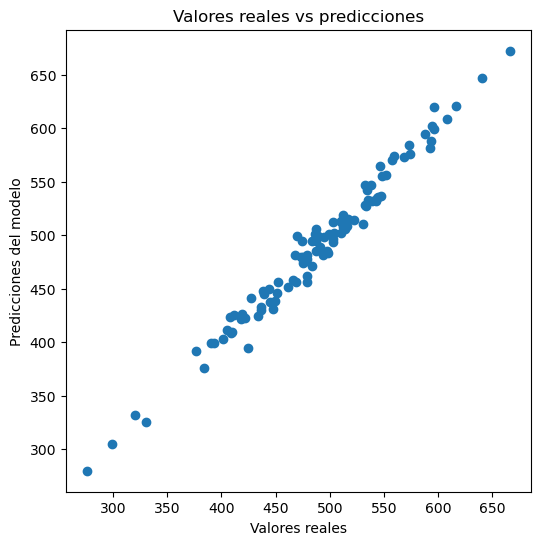

In [394]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Valores reales")
plt.ylabel("Predicciones del modelo")
plt.title("Valores reales vs predicciones")
plt.show()

## 9. Validación cruzada del modelo

Para evaluar de manera más robusta el desempeño del modelo se aplica la técnica de **validación cruzada (cross-validation)**.

La validación cruzada consiste en dividir el conjunto de datos en varias particiones o "folds". El modelo se entrena utilizando algunas de estas particiones y se evalúa con las restantes. Este proceso se repite varias veces cambiando la partición utilizada para prueba.

En este caso se utilizará **validación cruzada con 5 folds (K=5)**, lo que significa que el conjunto de datos se divide en cinco partes. El modelo se entrena cinco veces, utilizando cada vez una partición distinta como conjunto de validación.

Esta técnica permite obtener una estimación más confiable del desempeño del modelo y ayuda a detectar posibles problemas de **sobreajuste (overfitting)** o **subajuste (underfitting)**.

In [395]:
from sklearn.model_selection import cross_val_score

In [396]:
# Aplicar validación cruzada con 5 particiones
scores = cross_val_score(modelo, X, y, cv=5)

In [397]:
# Mostrar resultados de cada fold
print("Scores de validación cruzada:", scores)

Scores de validación cruzada: [0.98274654 0.9821047  0.98717189 0.9842572  0.98219012]


In [398]:
# Promedio de los resultados
print("Promedio de validación cruzada:", scores.mean())

Promedio de validación cruzada: 0.9836940897539079


### Interpretación de la validación cruzada

Los resultados de la validación cruzada muestran el desempeño del modelo en diferentes particiones del conjunto de datos.

El promedio de los scores obtenidos permite estimar el rendimiento esperado del modelo cuando se aplica a nuevos datos.

Valores consistentes entre los diferentes folds indican que el modelo presenta un comportamiento estable y que no depende excesivamente de una división específica del dataset.

## 10. Modelo de regresión polinomial

Además de la regresión lineal, es posible utilizar modelos más complejos que permitan capturar relaciones no lineales entre las variables.

La **regresión polinomial** transforma las variables originales en combinaciones polinómicas, permitiendo al modelo ajustar relaciones más complejas entre las variables predictoras y la variable objetivo.

En esta sección se entrenará un modelo de regresión polinomial y se comparará su desempeño con el modelo de regresión lineal previamente entrenado.

In [399]:
# Importar herramientas para regresión polinomial
from sklearn.preprocessing import PolynomialFeatures

In [400]:
# Crear transformador polinomial de grado 2
poly = PolynomialFeatures(degree=2)

# Transformar los datos de entrenamiento
X_train_poly = poly.fit_transform(X_train)

# Transformar los datos de prueba
X_test_poly = poly.transform(X_test)

In [401]:
# Crear modelo de regresión lineal para trabajar con las variables polinómicas
modelo_poly = LinearRegression()

In [402]:
# Entrenar el modelo polinomial
modelo_poly.fit(X_train_poly, y_train)

LinearRegression()

In [403]:
# Realizar predicciones con el modelo polinomial
y_pred_poly = modelo_poly.predict(X_test_poly)

In [404]:
# Calcular métricas para el modelo polinomial
mae_poly = mean_absolute_error(y_test, y_pred_poly)
mse_poly = mean_squared_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
r2_poly = r2_score(y_test, y_pred_poly)

print("MAE:", mae_poly)
print("MSE:", mse_poly)
print("RMSE:", rmse_poly)
print("R²:", r2_poly)

MAE: 8.836198350857817
MSE: 116.06979147185915
RMSE: 10.773569114822587
R²: 0.9765597536302036


### Comparación con la regresión lineal

El modelo de regresión polinomial permite capturar relaciones más complejas entre las variables del dataset.

Al comparar las métricas obtenidas con las del modelo de regresión lineal es posible evaluar si el aumento de complejidad del modelo mejora la precisión de las predicciones.

Si las métricas mejoran significativamente, el modelo polinomial puede representar mejor la relación entre las variables. En caso contrario, el modelo lineal puede ser suficiente para describir el comportamiento de los datos.

## 11. Algoritmos de clasificación (KNN)

En el aprendizaje automático existen dos tipos principales de problemas supervisados: regresión y clasificación.

En los problemas de **clasificación**, la variable objetivo corresponde a una categoría o clase. Por ejemplo, predecir si un cliente comprará o no un producto, o clasificar correos electrónicos como spam o no spam.

En cambio, en los problemas de **regresión**, la variable objetivo es numérica y continua. El objetivo del modelo es estimar un valor numérico.

En este proyecto se busca predecir el **gasto anual de los clientes (Yearly Amount Spent)**, que corresponde a un valor numérico continuo. Por esta razón, el problema se aborda mediante **modelos de regresión**.

Sin embargo, con fines educativos se implementará un modelo de **clasificación K-Nearest Neighbors (KNN)** sobre una versión simplificada del dataset, con el objetivo de comparar su comportamiento frente a los modelos de regresión.

In [405]:
# Crear una variable categórica basada en el gasto anual
df['Spending_Category'] = pd.qcut(
    df['Yearly Amount Spent'],
    q=3,
    labels=['Bajo', 'Medio', 'Alto']
)

In [406]:
# Variables predictoras
X_class = df.drop(['Yearly Amount Spent', 'Spending_Category'], axis=1)

# Variable objetivo categórica
y_class = df['Spending_Category']

In [407]:
# Dividir datos en entrenamiento y prueba
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42
)

In [408]:
from sklearn.neighbors import KNeighborsClassifier

In [409]:
# Crear modelo KNN
knn = KNeighborsClassifier(n_neighbors=5)

# Entrenar modelo
knn.fit(X_train_c, y_train_c)

KNeighborsClassifier()

In [410]:
# Predicciones
y_pred_knn = knn.predict(X_test_c)

# Evaluar precisión
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test_c, y_pred_knn)

print("Accuracy del modelo KNN:", accuracy)

Accuracy del modelo KNN: 0.86


### Interpretación

El modelo KNN fue aplicado sobre una versión categorizada del gasto anual de los clientes.

El modelo obtuvo una **precisión (accuracy) de aproximadamente 0.86**, lo que significa que el modelo clasificó correctamente cerca del **86% de los clientes** en sus respectivas categorías de gasto (bajo, medio o alto).

Sin embargo, este enfoque requiere transformar una variable numérica continua en categorías discretas, lo que implica una pérdida de información.

Por esta razón, los modelos de **regresión** resultan más adecuados para este problema, ya que permiten predecir directamente el valor numérico del gasto anual de los clientes en lugar de clasificarlo en categorías.

## 12. Optimización del modelo

Una vez entrenado el modelo base de regresión lineal, es posible mejorar su desempeño mediante técnicas de optimización.

En esta etapa se explorarán tres estrategias:

- **Ingeniería de características:** generar nuevas representaciones de las variables para capturar relaciones más complejas.
- **Regularización:** aplicar modelos como Ridge y Lasso que ayudan a evitar el sobreajuste penalizando coeficientes demasiado grandes.
- **Búsqueda de hiperparámetros:** utilizar GridSearchCV para encontrar automáticamente la mejor configuración del modelo.

Estas técnicas permiten mejorar la capacidad de generalización del modelo y obtener predicciones más robustas.

In [411]:
# Importar modelo Ridge
from sklearn.linear_model import Ridge

# Crear modelo Ridge
ridge_model = Ridge(alpha=1.0)

# Entrenar modelo
ridge_model.fit(X_train, y_train)

# Predicciones
y_pred_ridge = ridge_model.predict(X_test)

In [412]:
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("MAE Ridge:", mae_ridge)
print("RMSE Ridge:", rmse_ridge)
print("R2 Ridge:", r2_ridge)

MAE Ridge: 8.539230754571278
RMSE Ridge: 10.462076463420944
R2 Ridge: 0.9778955991604819


In [413]:
# Importar modelo Lasso
from sklearn.linear_model import Lasso

# Crear modelo
lasso_model = Lasso(alpha=0.1)

# Entrenar modelo
lasso_model.fit(X_train, y_train)

# Predicciones
y_pred_lasso = lasso_model.predict(X_test)

In [414]:
# Calcular métricas de evaluación para el modelo Lasso
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)

# Calcular la raíz del error cuadrático medio
rmse_lasso = np.sqrt(mse_lasso)

# Calcular coeficiente de determinación
r2_lasso = r2_score(y_test, y_pred_lasso)

# Mostrar resultados de las métricas
print("MAE Lasso:", mae_lasso)
print("RMSE Lasso:", rmse_lasso)
print("R2 Lasso:", r2_lasso)

MAE Lasso: 8.55266412838791
RMSE Lasso: 10.477392537865814
R2 Lasso: 0.9778308318145387


In [415]:
# Importar herramienta para búsqueda de hiperparámetros
from sklearn.model_selection import GridSearchCV


# Definir los valores del hiperparámetro alpha que serán evaluados
param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1, 10, 100]
}


# Crear el objeto GridSearchCV para encontrar el mejor valor de alpha
# Se utiliza el modelo Ridge y validación cruzada con 5 particiones
grid = GridSearchCV(Ridge(), param_grid, cv=5)


# Entrenar el modelo evaluando todas las combinaciones de parámetros
grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [0.001, 0.01, 0.1, 1, 10, 100]})

In [416]:
# Mostrar el mejor valor del hiperparámetro encontrado
print("Mejor parámetro:", grid.best_params_)

# Mostrar el mejor desempeño obtenido durante la validación cruzada
print("Mejor score:", grid.best_score_)

Mejor parámetro: {'alpha': 0.1}
Mejor score: 0.9848867112800269


### Interpretación

La optimización del modelo mediante regularización y búsqueda de hiperparámetros permite mejorar la estabilidad del modelo y reducir el riesgo de sobreajuste.

Los modelos Ridge y Lasso introducen penalizaciones sobre los coeficientes del modelo, lo que ayuda a controlar la complejidad del modelo.

El uso de GridSearchCV permite identificar automáticamente la mejor configuración del parámetro de regularización, obteniendo un modelo más robusto y mejor adaptado a los datos.

## 13. Modelo de Gradient Boosting

En esta etapa se implementa un modelo más avanzado basado en técnicas de **ensemble learning**, específicamente **Gradient Boosting Regressor**.

El boosting es una estrategia que combina múltiples modelos simples, entrenados de forma secuencial, con el objetivo de corregir progresivamente los errores de los modelos anteriores.

A diferencia de la regresión lineal, este enfoque puede capturar relaciones más complejas entre las variables y mejorar el desempeño predictivo.

En esta sección se entrenará un modelo de Gradient Boosting, se evaluará su rendimiento y se comparará con los modelos previamente desarrollados.

In [417]:
# Importar modelo Gradient Boosting Regressor
from sklearn.ensemble import GradientBoostingRegressor

In [418]:
# Crear modelo Gradient Boosting Regressor
gbr_model = GradientBoostingRegressor(random_state=42)

In [419]:
# Entrenar el modelo con los datos de entrenamiento
gbr_model.fit(X_train, y_train)

GradientBoostingRegressor(random_state=42)

In [420]:
# Realizar predicciones sobre el conjunto de prueba
y_pred_gbr = gbr_model.predict(X_test)

In [421]:
# Calcular métricas de evaluación para el modelo Gradient Boosting
mae_gbr = mean_absolute_error(y_test, y_pred_gbr)
mse_gbr = mean_squared_error(y_test, y_pred_gbr)
rmse_gbr = np.sqrt(mse_gbr)
r2_gbr = r2_score(y_test, y_pred_gbr)

# Mostrar resultados de las métricas
print("MAE Gradient Boosting:", mae_gbr)
print("RMSE Gradient Boosting:", rmse_gbr)
print("R2 Gradient Boosting:", r2_gbr)

MAE Gradient Boosting: 11.789933768880154
RMSE Gradient Boosting: 14.707045038974993
R2 Gradient Boosting: 0.956318875237348


### Interpretación

El modelo de **Gradient Boosting Regressor** fue entrenado con el objetivo de capturar relaciones más complejas entre las variables predictoras y el gasto anual de los clientes.

Las métricas obtenidas permiten comparar su desempeño frente a los modelos anteriores, como la regresión lineal, la regresión polinomial y los modelos regularizados.

Si el modelo presenta menores errores (MAE y RMSE) y un valor de R² más alto, se puede concluir que ofrece una mejor capacidad predictiva. Sin embargo, también es importante considerar que se trata de un modelo más complejo y menos interpretable que una regresión lineal.

In [422]:
# Crear tabla comparativa de métricas
resultados = pd.DataFrame({
    'Modelo': ['Regresión Lineal', 'Regresión Polinomial', 'Ridge', 'Lasso', 'Gradient Boosting'],
    'MAE': [mae, mae_poly, mae_ridge, mae_lasso, mae_gbr],
    'RMSE': [rmse, rmse_poly, rmse_ridge, rmse_lasso, rmse_gbr],
    'R2': [r2, r2_poly, r2_ridge, r2_lasso, r2_gbr]
})

# Mostrar tabla comparativa
resultados

,Modelo,MAE,RMSE,R2
0,Regresión Lineal,8.558442,10.481591,0.977813
1,Regresión Polinomial,8.836198,10.773569,0.976560
2,Ridge,8.539231,10.462076,0.977896
3,Lasso,8.552664,10.477393,0.977831
4,Gradient Boosting,11.789934,14.707045,0.956319


In [423]:
# Ordenar los resultados por RMSE (de menor a mayor)
resultados.sort_values(by="RMSE")

,Modelo,MAE,RMSE,R2
2,Ridge,8.539231,10.462076,0.977896
3,Lasso,8.552664,10.477393,0.977831
0,Regresión Lineal,8.558442,10.481591,0.977813
1,Regresión Polinomial,8.836198,10.773569,0.976560
4,Gradient Boosting,11.789934,14.707045,0.956319


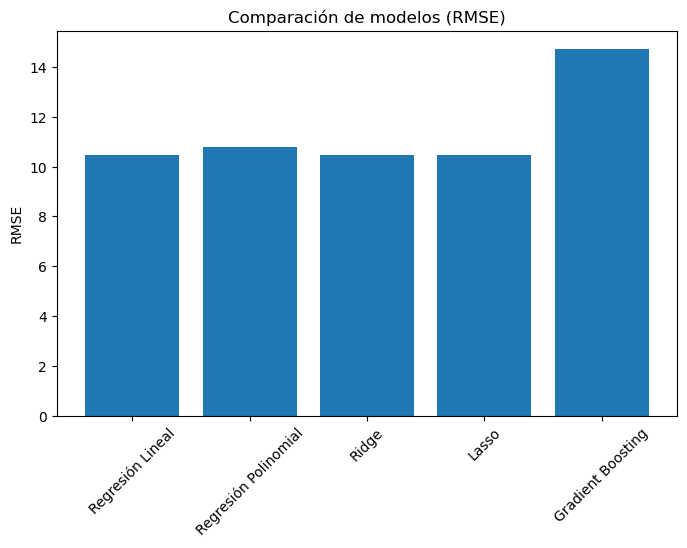

In [424]:
plt.figure(figsize=(8,5))

plt.bar(resultados["Modelo"], resultados["RMSE"])

plt.title("Comparación de modelos (RMSE)")
plt.ylabel("RMSE")
plt.xticks(rotation=45)

plt.show()

### Comparación final de modelos

La tabla anterior permite comparar el desempeño de los distintos modelos implementados a lo largo del proyecto.

En general, un mejor modelo será aquel que presente:

- menores valores de **MAE**
- menores valores de **RMSE**
- mayor valor de **R²**

A partir de esta comparación es posible seleccionar el modelo final más adecuado, considerando tanto su precisión como su capacidad de generalización.

### Ventajas y limitaciones del enfoque ensemble

**Ventajas:**
- Puede capturar relaciones no lineales complejas.
- Suele ofrecer mejor desempeño predictivo que modelos lineales simples.
- Reduce errores de forma progresiva al corregir iterativamente las predicciones anteriores.

**Limitaciones:**
- Es menos interpretable que una regresión lineal.
- Requiere mayor tiempo de entrenamiento.
- Puede ser más sensible a la elección de hiperparámetros.

## 14. Conclusiones

A lo largo de este proyecto se aplicaron diferentes técnicas de aprendizaje automático para predecir el gasto anual de clientes de una plataforma de comercio electrónico.

El problema fue abordado como un **problema de regresión supervisada**, ya que la variable objetivo corresponde a un valor numérico continuo.

Se implementaron diversos modelos, incluyendo regresión lineal, regresión polinomial, modelos regularizados (Ridge y Lasso), un modelo de clasificación KNN con fines comparativos y un modelo de Gradient Boosting.

La comparación de métricas mostró que el modelo **Ridge Regression** obtuvo el mejor desempeño, presentando el menor error (MAE y RMSE) y el mayor coeficiente de determinación (R² ≈ 0.978). Esto indica que el modelo logra explicar aproximadamente el 97.8% de la variabilidad del gasto anual de los clientes.

Los resultados también muestran que modelos más complejos, como Gradient Boosting, no necesariamente mejoran el rendimiento cuando los datos presentan relaciones mayormente lineales.

En conclusión, para este conjunto de datos, los modelos lineales regularizados ofrecen un buen equilibrio entre **precisión, estabilidad e interpretabilidad**, siendo una alternativa adecuada para la predicción del gasto anual de los clientes.